<a href="https://colab.research.google.com/github/jxcact-sketch/Joshua-s-Research-Project/blob/main/Joshua's%20Research%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install pandas
import pandas as pd

url = '/content/hurdat2_atlantic_1851_2025_filtered.csv'
df = pd.read_csv(url)

!pip install matplotlib
import matplotlib.pyplot as plt


df.head()
df.shape
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   storm_id           55605 non-null  object 
 1   name               55605 non-null  object 
 2   date               55605 non-null  object 
 3   time               55605 non-null  int64  
 4   record_identifier  1256 non-null   object 
 5   status             55605 non-null  object 
 6   latitude           55605 non-null  float64
 7   longitude          55605 non-null  float64
 8   max_wind_knots     55605 non-null  int64  
 9   min_pressure_mb    24659 non-null  float64
 10  year               55605 non-null  int64  
 11  month              55605 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 5.1+ MB


,storm_id,name,date,time,record_identifier,status,latitude,longitude,max_wind_knots,min_pressure_mb,year,month
0,AL011851,UNNAMED,1851-06-25,0,NaN,HU,28.0,-94.8,80,NaN,1851,6
1,AL011851,UNNAMED,1851-06-25,600,NaN,HU,28.0,-95.4,80,NaN,1851,6
2,AL011851,UNNAMED,1851-06-25,1200,NaN,HU,28.0,-96.0,80,NaN,1851,6
3,AL011851,UNNAMED,1851-06-25,1800,NaN,HU,28.1,-96.5,80,NaN,1851,6
4,AL011851,UNNAMED,1851-06-25,2100,L,HU,28.2,-96.8,80,NaN,1851,6
...,...,...,...,...,...,...,...,...,...,...,...,...
55600,AL132025,MELISSA,2025-10-31,600,NaN,HU,34.5,-65.5,75,972.0,2025,10
55601,AL132025,MELISSA,2025-10-31,1200,NaN,EX,37.7,-62.1,75,972.0,2025,10
55602,AL132025,MELISSA,2025-10-31,1800,NaN,EX,40.6,-58.9,70,972.0,2025,10
55603,AL132025,MELISSA,2025-11-01,0,NaN,EX,43.7,-56.0,70,971.0,2025,11


In [ ]:
df['storm_id'].value_counts(dropna=False)

,count
storm_id,
AL031899,133
AL141971,118
AL201969,101
AL142012,96
AL061966,96
...,...
AL021853,1
AL011855,1
AL011853,1


In [ ]:
df.isna().sum()


,0
storm_id,0
name,0
date,0
time,0
record_identifier,54349
status,0
latitude,0
longitude,0
max_wind_knots,0
min_pressure_mb,30946


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,time,latitude,longitude,max_wind_knots,min_pressure_mb,year,month
count,55605.000000,55605.000000,55605.000000,55605.000000,24659.000000,55605.000000,55605.000000
mean,910.789335,27.351904,-64.790028,52.562306,992.218541,1957.346857,8.748080
std,671.467118,10.387506,20.204905,25.102548,19.323985,47.227005,1.364212
min,0.000000,7.000000,-136.900000,-99.000000,882.000000,1851.000000,1.000000
25%,600.000000,19.200000,-80.600000,35.000000,984.000000,1921.000000,8.000000
50%,1200.000000,26.700000,-67.000000,45.000000,999.000000,1965.000000,9.000000
75%,1800.000000,33.600000,-51.000000,70.000000,1006.000000,1999.000000,10.000000
max,2330.000000,83.000000,63.000000,165.000000,1024.000000,2025.000000,12.000000


In [ ]:
df['storm_id'].unique()

array(['AL011851', 'AL021851', 'AL031851', ..., 'AL112025', 'AL122025',
       'AL132025'], dtype=object)

Research Quesetions:
1. How have hurricane speeds changed over time.
2. When do the most amnount of hurricanes occur during the year
3. How many hurricanes are there per year.

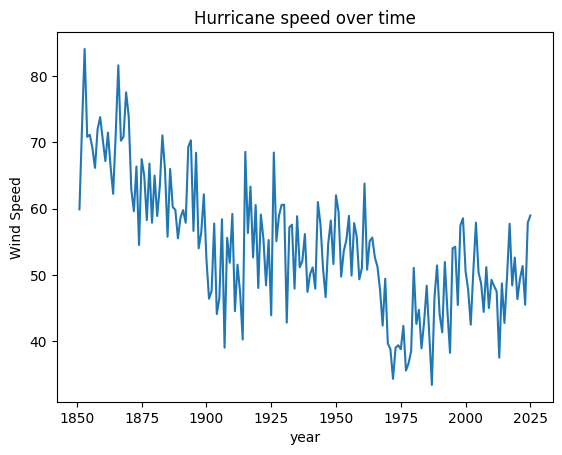

In [ ]:
avg_wind = df.groupby('year')['max_wind_knots'].mean()

x = avg_wind.index
y = avg_wind.values

plt.plot (x,y)
plt.title('Hurricane speed over time')
plt.xlabel('year')
plt.ylabel('Wind Speed')
plt.show()

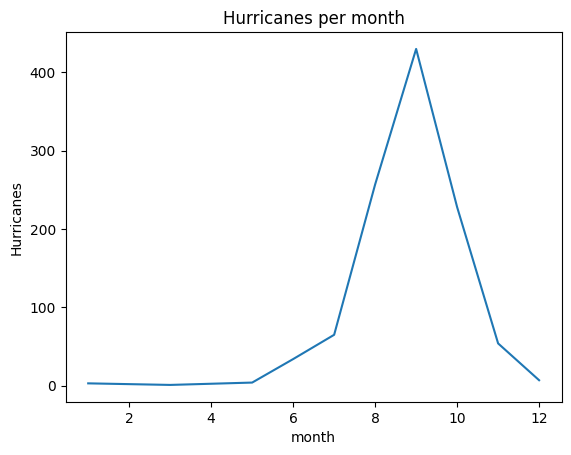

In [ ]:
hurricanes = df[df['status'] == 'HU']

hurricanes = hurricanes[['month', 'storm_id']].drop_duplicates()

hurricane_per_month = hurricanes.groupby('month')['storm_id'].count()

x = hurricane_per_month.index
y = hurricane_per_month.values

plt.plot (x,y)
plt.title('Hurricanes per month')
plt.xlabel('month')
plt.ylabel('Hurricanes')
plt.show()

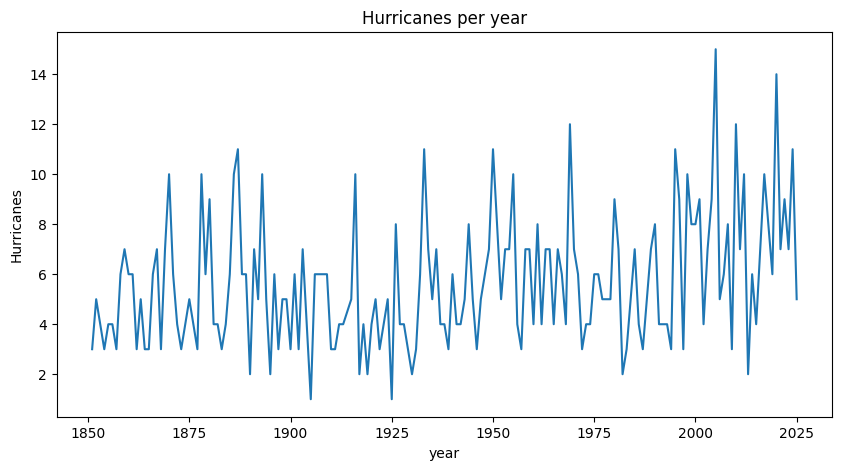

In [ ]:
hurricanes = df[df['status'] == 'HU']

hurricanes = hurricanes[['year', 'storm_id']].drop_duplicates()

hurricane_per_year = hurricanes.groupby('year')['storm_id'].count()

x = hurricane_per_year.index
y = hurricane_per_year.values

width = 10
height = 5
plt.figure(figsize=(width, height))

plt.plot (x,y)
plt.title('Hurricanes per year')
plt.xlabel('year')
plt.ylabel('Hurricanes')

plt.show()

In [ ]:
yearly_df = pd.DataFrame(hurricane_per_year)
print(yearly_df.head())
print(yearly_df.columns)

      storm_id
year          
1851         3
1852         5
1853         4
1854         3
1855         4
Index(['storm_id'], dtype='object')


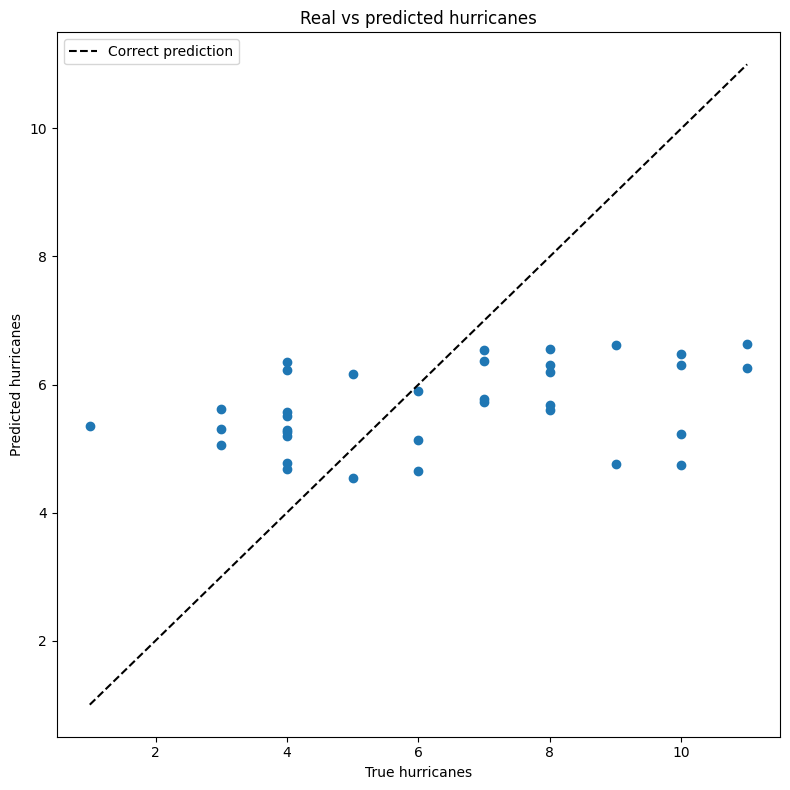

In [ ]:
!pip install scikit-learn

import sklearn
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import *

url = '/content/hurdat2_atlantic_1851_2025_filtered.csv'
df = pd.read_csv(url)

hurricanes = df[df['status'] == 'HU']

hurricanes = hurricanes[['year', 'storm_id']].drop_duplicates()

hurricanes_per_year = hurricanes.groupby('year')['storm_id'].count()

yearly_df = pd.DataFrame({
    "year": hurricanes_per_year.index,
    "hurricanes": hurricanes_per_year
})

features = yearly_df[['year']]
labels = yearly_df['hurricanes']

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2)

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

pred = lr_model.predict(X_test)

plt.figure(figsize=(8, 8))

MIN_VALUE = min(y_test)
MAX_VALUE = max(y_test)

plt.scatter(y_test, pred)
plt.plot([MIN_VALUE, MAX_VALUE], [MIN_VALUE, MAX_VALUE], '--k', label="Correct prediction")


plt.axis('tight')


plt.xlabel('True hurricanes')
plt.ylabel('Predicted hurricanes')
plt.title("Real vs predicted hurricanes")

plt.legend()
plt.tight_layout()



In [ ]:
import pandas as pd
import numpy as np

import scipy.stats as stats

hurricanes = df[df['status'] == 'HU']

hurricanes = hurricanes[['year', 'storm_id']].drop_duplicates()

hurricanes_per_year = hurricanes.groupby('year')['storm_id'].count()

before_1980 = hurricanes_per_year.loc[hurricanes_per_year.index < 1980]

after_1980 = hurricanes_per_year.loc[hurricanes_per_year.index >= 1980]

t_stat, p_val = stats.ttest_ind(before_1980, after_1980)

print("T-statistic:", t_stat)
print("P-value:", p_val)

#Reject null hypthesis

before_1980.mean()



T-statistic: -3.7900639990811062
P-value: 0.00020848304535390848


np.float64(5.228346456692913)

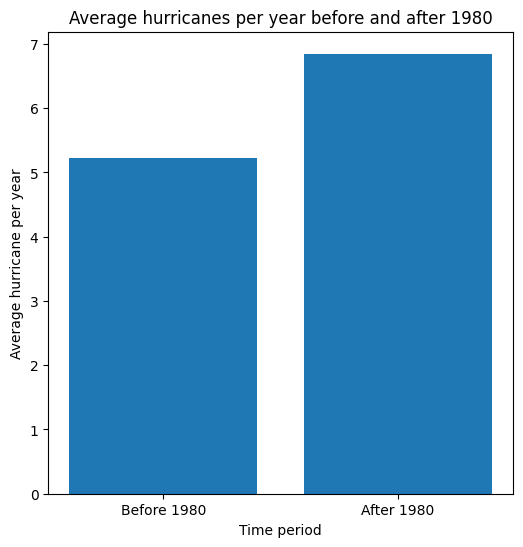

In [ ]:
!pip install matplotlib
import matplotlib.pyplot as plt

hurricanes = df[df['status'] == 'HU']

hurricanes = hurricanes[['year', 'storm_id']].drop_duplicates()

hurricanes_per_year = hurricanes.groupby('year')['storm_id'].count()

before_1980 = hurricanes_per_year.loc[hurricanes_per_year.index < 1980]

after_1980 = hurricanes_per_year.loc[hurricanes_per_year.index >= 1980]

x = ['Before 1980', 'After 1980']
y = [before_1980.mean(), after_1980.mean()]

width = 6
height = 6
plt.figure(figsize=(width, height))

plt.bar(x,y)

plt.title('Average hurricanes per year before and after 1980')
plt.xlabel('Time period')
plt.ylabel('Average hurricane per year')

plt.show()

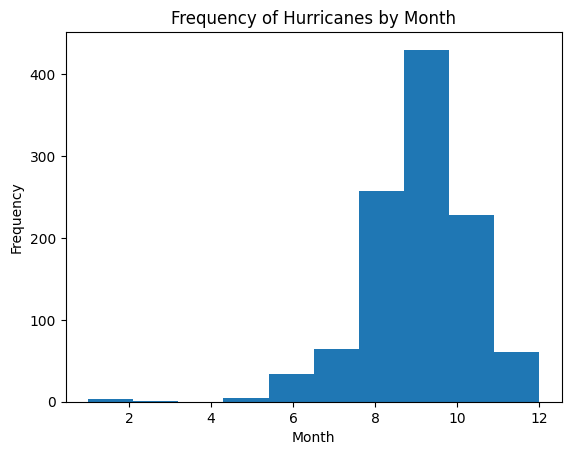

In [ ]:
hurricanes = df[df['status'] == 'HU']

hurricanes = hurricanes[['month', 'storm_id']].drop_duplicates()

plt.hist(hurricanes['month'])

plt.title('Frequency of Hurricanes by Month')
plt.xlabel('Month')
plt.ylabel('Frequency')

plt.show()

In [ ]:
!jupyter nbconvert --to PDF 'Joshua's Research Project (Hurricanes)'
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc !pip install pypandoc

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `jupyter nbconvert --to PDF 'Joshua's Research Project (Hurricanes)''
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package !pip
E: Couldn't find any package by glob '!pip'
E: Unable to locate package install
E: Unable to locate package pypandoc
